# 🚨 AI 911 Emergency Operator: Fine-Tuning Gemma-2B with LoRA

## 1. Project Overview

This notebook demonstrates **domain-specific fine-tuning** of Google's Gemma-2B-IT model to simulate a professional 911 emergency operator. Using **LoRA (Low-Rank Adaptation)** and **4-bit quantization**, we transform a general-purpose language model into one that can generate realistic, context-appropriate emergency dispatch responses.

### Why This Matters
Off-the-shelf LLMs like Gemma-2B-IT are trained for general conversation. When presented with emergency scenarios, the base model defaults to generic advice like "call 911" — even when the caller *is already on 911*. Fine-tuning teaches the model the specific communication patterns, protocols, and urgency required for emergency dispatch.

### Key Techniques Demonstrated
- **LoRA Fine-Tuning**: Parameter-efficient adaptation using only ~0.78% of total model parameters
- **4-bit Quantization (NF4)**: Reducing model memory footprint by ~4x to fit on a T4 GPU
- **Hyperparameter Search**: Systematic comparison of 3 training configurations
- **Conversation-Format Training**: Using Gemma's native chat template for multi-turn dialogue

### Project Pipeline
Dataset → Preprocessing → Gemma Formatting → Tokenization → Training (3 configs) → Evaluation → Deployment

In [5]:
!pip install -q transformers>=4.38.0 datasets accelerate peft bitsandbytes
!pip install -q evaluate rouge_score scikit-learn matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [6]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Clear GPU memory
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB used")


GPU available: True
GPU name: Tesla T4
GPU memory: 2.07 GB used


In [7]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter

import torch
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    TrainerCallback,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import evaluate

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected! Go to Runtime → Change runtime type → T4 GPU")

Using device: cuda
GPU: Tesla T4
Memory: 15.8 GB


## 2. Dataset: Real 911 Call Transcripts

We use the [`spikecodes/911-call-transcripts`](https://huggingface.co/datasets/spikecodes/911-call-transcripts) dataset from HuggingFace, which contains **518 real emergency call transcripts** formatted as multi-turn conversations.

### Dataset Characteristics
Each example is a complete 911 call with alternating `assistant` (operator) and `user` (caller) messages. Key challenges in this dataset include:

- **Consecutive same-role messages**: Operators or callers sometimes speak multiple times in a row (2,164 instances), which violates Gemma's strict user/model alternation requirement
- **Null/empty messages**: 12 messages with missing content that need filtering
- **Variable conversation lengths**: Calls range from brief exchanges to extended multi-party conversations

### Preprocessing Strategy
1. **Remove** null/empty messages
2. **Merge** consecutive same-role messages into single turns
3. **Filter** conversations with fewer than 4 turns (too short to be meaningful)
4. **Format** for Gemma's strict user→model→user→model alternation pattern

In [8]:
print("Loading dataset...")
raw_dataset = load_dataset("spikecodes/911-call-transcripts")
print(f"Dataset structure: {raw_dataset}")
print(f"Total examples: {len(raw_dataset['train'])}")

# Analyze dataset
def analyze_dataset(dataset):
    """Analyze dataset characteristics"""
    stats = {
        "total_conversations": len(dataset),
        "turns_per_call": [],
        "operator_response_lengths": [],
        "caller_message_lengths": [],
        "consecutive_same_role": 0,
        "null_messages": 0
    }

    for example in dataset:
        messages = example["messages"]
        stats["turns_per_call"].append(len(messages))

        prev_role = None
        for msg in messages:
            content = msg.get("content")
            if content is None or content.strip() == "":
                stats["null_messages"] += 1
                continue

            word_count = len(content.split())
            if msg["role"] == "assistant":
                stats["operator_response_lengths"].append(word_count)
            else:
                stats["caller_message_lengths"].append(word_count)

            if msg["role"] == prev_role:
                stats["consecutive_same_role"] += 1
            prev_role = msg["role"]

    print("=" * 60)
    print("DATASET STATISTICS")
    print("=" * 60)
    print(f"Total conversations: {stats['total_conversations']}")
    print(f"Avg turns per call: {np.mean(stats['turns_per_call']):.1f}")
    print(f"Avg operator response: {np.mean(stats['operator_response_lengths']):.1f} words")
    print(f"Avg caller message: {np.mean(stats['caller_message_lengths']):.1f} words")
    print(f"Consecutive same-role messages: {stats['consecutive_same_role']} (need merging)")
    print(f"Null/empty messages: {stats['null_messages']}")

    return stats

dataset_stats = analyze_dataset(raw_dataset["train"])

Loading dataset...


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

calls.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/518 [00:00<?, ? examples/s]

Dataset structure: DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 518
    })
})
Total examples: 518
DATASET STATISTICS
Total conversations: 518
Avg turns per call: 50.0
Avg operator response: 8.7 words
Avg caller message: 7.8 words
Consecutive same-role messages: 2164 (need merging)
Null/empty messages: 12


In [9]:
def preprocess_conversation(example):
    """Clean and preprocess 911 call transcripts"""
    messages = example["messages"]
    cleaned = []

    for msg in messages:
        content = msg.get("content")
        if content is None or content.strip() == "":
            continue

        content = " ".join(content.split())

        # Merge consecutive same-role messages
        if cleaned and cleaned[-1]["role"] == msg["role"]:
            cleaned[-1]["content"] += " " + content
        else:
            cleaned.append({
                "role": msg["role"],
                "content": content
            })

    return {
        "messages": cleaned,
        "num_turns": len(cleaned),
        "valid": len(cleaned) >= 4
    }

print("Preprocessing conversations...")
processed = raw_dataset["train"].map(preprocess_conversation)
cleaned_dataset = processed.filter(lambda x: x["valid"])

print(f"Original: {len(raw_dataset['train'])} conversations")
print(f"After cleaning: {len(cleaned_dataset)} conversations")

Preprocessing conversations...


Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Filter:   0%|          | 0/518 [00:00<?, ? examples/s]

Original: 518 conversations
After cleaning: 516 conversations


## 3. Data Splitting Strategy

We split the cleaned dataset into three partitions using a **70/15/15** ratio:

| Split | Purpose | Size |
|-------|---------|------|
| **Train** | Model learns emergency operator patterns | 361 examples |
| **Validation** | Monitor overfitting during training; select best checkpoint | 77 examples |
| **Test** | Final, unbiased evaluation of model performance | 78 examples |

All splits use `seed=42` for reproducibility. The validation set is critical for our `load_best_model_at_end=True` strategy — the Trainer automatically saves the checkpoint with the lowest validation loss.

In [10]:
def create_splits(dataset, train_ratio=0.70, val_ratio=0.15, seed=42):
    """Create 70/15/15 splits"""
    train_testval = dataset.train_test_split(test_size=(1 - train_ratio), seed=seed, shuffle=True)
    val_test = train_testval["test"].train_test_split(test_size=0.5, seed=seed)

    return DatasetDict({
        "train": train_testval["train"],
        "validation": val_test["train"],
        "test": val_test["test"]
    })

dataset_splits = create_splits(cleaned_dataset)

print("=" * 60)
print("DATASET SPLITS")
print("=" * 60)
print(f"Train:      {len(dataset_splits['train'])} examples")
print(f"Validation: {len(dataset_splits['validation'])} examples")
print(f"Test:       {len(dataset_splits['test'])} examples")

DATASET SPLITS
Train:      361 examples
Validation: 77 examples
Test:       78 examples


## 4. Gemma-Specific Conversation Formatting

Gemma models enforce **strict alternation** between `user` and `model` roles. Our raw 911 transcripts don't follow this pattern (operators and callers sometimes speak consecutively), so we need a custom formatting step.

### Formatting Rules
| Situation | Solution |
|-----------|----------|
| Operator speaks when it's caller's turn | Insert `"Caller: [listening]"` placeholder before operator response |
| Caller speaks when it's operator's turn | Insert `"Go ahead."` placeholder before caller message |
| Conversation ends on caller turn | Append `"Help is on the way."` to ensure model-final format |

### Role Mapping
- **Original `assistant`** → Gemma `model` (the 911 operator we're training)
- **Original `user`** → Gemma `user` (prefixed with `"Caller:"` for context)

This formatting ensures every training example is valid input for Gemma's chat template while preserving the natural flow of emergency conversations.

In [12]:

from huggingface_hub import login

print("=" * 60)
print("HUGGINGFACE AUTHENTICATION")
print("=" * 60)
print("1. Accept license: https://huggingface.co/google/gemma-2b-it")
print("2. Get token: https://huggingface.co/settings/tokens")
print()
login()

HUGGINGFACE AUTHENTICATION
1. Accept license: https://huggingface.co/google/gemma-2b-it
2. Get token: https://huggingface.co/settings/tokens



In [11]:
MODEL_ID = "google/gemma-2b-it"

def format_for_gemma(example):
    """Format with STRICT user/model alternation for Gemma"""
    messages = example["messages"]
    formatted = []
    expected_role = "user"

    for msg in messages:
        current_role = "model" if msg["role"] == "assistant" else "user"

        if current_role == expected_role:
            if current_role == "user":
                formatted.append({"role": "user", "content": f"Caller: {msg['content']}"})
                expected_role = "model"
            else:
                formatted.append({"role": "model", "content": msg["content"]})
                expected_role = "user"
        else:

            if current_role == "model" and expected_role == "user":
                formatted.append({"role": "user", "content": "Caller: [listening]"})
                formatted.append({"role": "model", "content": msg["content"]})
                expected_role = "user"
            elif current_role == "user" and expected_role == "model":
                formatted.append({"role": "model", "content": "Go ahead."})
                formatted.append({"role": "user", "content": f"Caller: {msg['content']}"})
                expected_role = "model"

    # Ensure ends with model
    if formatted and formatted[-1]["role"] == "user":
        formatted.append({"role": "model", "content": "Help is on the way."})

    valid = len(formatted) >= 4 and formatted[0]["role"] == "user"

    return {"messages_formatted": formatted, "valid": valid}

print("Formatting for Gemma...")
formatted_splits = DatasetDict({
    split: dataset_splits[split].map(format_for_gemma)
    for split in dataset_splits
})

# Filter invalid
formatted_splits = DatasetDict({
    split: formatted_splits[split].filter(lambda x: x["valid"])
    for split in formatted_splits
})

print(f"Train: {len(formatted_splits['train'])} | Val: {len(formatted_splits['validation'])} | Test: {len(formatted_splits['test'])}")

sample_roles = [m['role'] for m in formatted_splits['train'][0]['messages_formatted'][:6]]
print(f"Sample roles: {sample_roles}")


Formatting for Gemma...


Map:   0%|          | 0/361 [00:00<?, ? examples/s]

Map:   0%|          | 0/77 [00:00<?, ? examples/s]

Map:   0%|          | 0/78 [00:00<?, ? examples/s]

Filter:   0%|          | 0/361 [00:00<?, ? examples/s]

Filter:   0%|          | 0/77 [00:00<?, ? examples/s]

Filter:   0%|          | 0/78 [00:00<?, ? examples/s]

Train: 361 | Val: 77 | Test: 78
Sample roles: ['user', 'model', 'user', 'model', 'user', 'model']


In [13]:
print(f"Loading tokenizer for {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"✅ Tokenizer loaded! Vocab size: {tokenizer.vocab_size:,}")


Loading tokenizer for google/gemma-2b-it...
✅ Tokenizer loaded! Vocab size: 256,000


## 5. Model Loading: 4-bit Quantization

We load Gemma-2B-IT with aggressive memory optimization to fit within the **T4 GPU's 15.8 GB** memory budget.

### BitsAndBytes Quantization Config
| Parameter | Value | Purpose |
|-----------|-------|---------|
| `load_in_4bit` | `True` | Reduces model size by ~4x (from ~10GB to ~3GB) |
| `bnb_4bit_quant_type` | `"nf4"` | NormalFloat4 — optimal quantization scheme for pretrained LLM weights |
| `bnb_4bit_compute_dtype` | `float16` | Computation precision during forward/backward passes |
| `bnb_4bit_use_double_quant` | `True` | Quantizes the quantization constants themselves for additional savings |

### Memory Budget
After quantization, the model occupies ~3.09 GB, leaving sufficient room for:
- LoRA adapter weights (~75 MB)
- Optimizer states (paged AdamW 8-bit)
- Gradient computation and activation caching
- Tokenized batch data

In [14]:
print(f"Loading {MODEL_ID} with 4-bit quantization...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model)
print(f"✅ Model loaded! Memory: {model.get_memory_footprint() / 1e9:.2f} GB")

Loading google/gemma-2b-it with 4-bit quantization...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

✅ Model loaded! Memory: 3.09 GB


## 6. LoRA: Parameter-Efficient Fine-Tuning

Rather than updating all 2.5 billion parameters, **LoRA** injects small trainable matrices into specific attention and feed-forward layers. This dramatically reduces memory requirements and training time while preserving the base model's general capabilities.

### How LoRA Works
For a pretrained weight matrix $W \in \mathbb{R}^{d \times k}$, LoRA adds a low-rank decomposition:

$$W' = W + \Delta W = W + BA$$

where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$, with rank $r \ll \min(d, k)$.

### Our Configuration
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `r` | 16 | Rank of adaptation matrices — balances capacity vs. efficiency |
| `lora_alpha` | 32 | Scaling factor (alpha/r = 2.0) — controls adaptation magnitude |
| `target_modules` | All attention + FFN projections | Maximum adaptation surface across 7 module types |
| `lora_dropout` | 0.05 | Light regularization to prevent overfitting on 361 examples |

### Efficiency
- **Trainable parameters**: 19.6M (0.78% of total)
- **Frozen parameters**: 2.5B (99.22% of total)
- This means we're adapting the model's behavior using less than 1% of its parameters.

In [15]:
LORA_CONFIG = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, LORA_CONFIG)

print("=" * 60)
print("LORA CONFIGURATION")
print("=" * 60)
model.print_trainable_parameters()

LORA CONFIGURATION
trainable params: 19,611,648 || all params: 2,525,784,064 || trainable%: 0.7765


## 7. Tokenization: Converting Conversations to Token Sequences

This step transforms our formatted conversations into the numerical sequences the model actually processes.

### Pipeline
1. **Apply Gemma's chat template** — wraps each message with special tokens (`<start_of_turn>user`, `<start_of_turn>model`, etc.)
2. **Tokenize** — converts text to token IDs using Gemma's 256K vocabulary
3. **Truncate** to 512 tokens — a memory constraint that captures the first ~8-12 turns of each conversation
4. **Create labels** — copy of `input_ids` for causal language modeling loss (the model learns to predict each next token)

### Design Decision: MAX_LENGTH = 512
This is a trade-off between context length and GPU memory. With batch size 1 and gradient accumulation of 16, 512 tokens per example keeps us within the T4's memory budget. Longer conversations are truncated, meaning the model primarily learns from early-to-mid conversation patterns (the most critical phase of a 911 call).

In [16]:
MAX_LENGTH = 512

def tokenize_single(example):
    """Tokenize a single example"""
    messages = example["messages_formatted"]

    try:
        tokenized = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=False,
            tokenize=True,
            return_dict=True,
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
        )

        return {
            "input_ids": tokenized["input_ids"],
            "attention_mask": tokenized["attention_mask"],
            "labels": tokenized["input_ids"].copy(),
            "tokenize_success": True
        }
    except Exception as e:
        return {
            "input_ids": [],
            "attention_mask": [],
            "labels": [],
            "tokenize_success": False
        }

print("Tokenizing datasets...")
tokenized_splits = {}

for split in formatted_splits:
    print(f"  Processing {split}...")
    tokenized = formatted_splits[split].map(
        tokenize_single,
        remove_columns=formatted_splits[split].column_names,
    )
    tokenized = tokenized.filter(lambda x: x["tokenize_success"])
    tokenized = tokenized.remove_columns(["tokenize_success"])
    tokenized_splits[split] = tokenized

tokenized_datasets = DatasetDict(tokenized_splits)

print(f"\n✅ Tokenization complete!")
print(f"   Train: {len(tokenized_datasets['train'])}")
print(f"   Validation: {len(tokenized_datasets['validation'])}")
print(f"   Test: {len(tokenized_datasets['test'])}")

if len(tokenized_datasets['train']) > 0:
    sample = tokenized_datasets['train'][0]
    print(f"\nSample length: {len(sample['input_ids'])} tokens")


Tokenizing datasets...
  Processing train...


Map:   0%|          | 0/361 [00:00<?, ? examples/s]

Filter:   0%|          | 0/361 [00:00<?, ? examples/s]

  Processing validation...


Map:   0%|          | 0/77 [00:00<?, ? examples/s]

Filter:   0%|          | 0/77 [00:00<?, ? examples/s]

  Processing test...


Map:   0%|          | 0/78 [00:00<?, ? examples/s]

Filter:   0%|          | 0/78 [00:00<?, ? examples/s]


✅ Tokenization complete!
   Train: 361
   Validation: 77
   Test: 78

Sample length: 512 tokens


## 8. Experimental Design: Three Hyperparameter Configurations

We systematically compare three training strategies to find the optimal configuration. All share the same architecture (LoRA r=16) and data pipeline — only the training dynamics differ.

### Configurations at a Glance

| Config | Learning Rate | Epochs | Warmup | Hypothesis |
|--------|:---:|:---:|:---:|------------|
| **Baseline** | 2e-4 | 3 | 10% | Standard LoRA defaults — our control experiment |
| **Conservative** | 5e-5 | 5 | 15% | Lower LR + more epochs may find a better minimum without overshooting |
| **Aggressive** | 3e-4 | 3 | 5% | Higher LR may converge faster on this small dataset |

### Shared Settings
- **Batch size**: 1 (with gradient accumulation of 16 → effective batch of 16)
- **Optimizer**: Paged AdamW 8-bit (memory-efficient)
- **Precision**: FP16 mixed precision
- **Early stopping criteria**: Best model selected by lowest validation loss
- **Weight decay**: 0.01

In [ ]:

class LoggingCallback(TrainerCallback):
    """Custom callback for logging"""
    def __init__(self):
        self.history = []
        self.start_time = None

    def on_train_begin(self, args, state, control, **kwargs):
        self.start_time = datetime.now()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            self.history.append({"step": state.global_step, "epoch": state.epoch, **logs})

    def on_train_end(self, args, state, control, **kwargs):
        duration = (datetime.now() - self.start_time).total_seconds() / 60
        print(f"Training completed in {duration:.1f} minutes")

# Hyperparameter configurations
HYPERPARAMETER_CONFIGS = {
    "config_1_baseline": {
        "learning_rate": 2e-4,
        "per_device_train_batch_size": 1,
        "gradient_accumulation_steps": 16,
        "num_train_epochs": 3,
        "warmup_ratio": 0.1,
    },
    "config_2_conservative": {
        "learning_rate": 5e-5,
        "per_device_train_batch_size": 1,
        "gradient_accumulation_steps": 16,
        "num_train_epochs": 5,
        "warmup_ratio": 0.15,
    },
    "config_3_aggressive": {
        "learning_rate": 3e-4,
        "per_device_train_batch_size": 1,
        "gradient_accumulation_steps": 16,
        "num_train_epochs": 3,
        "warmup_ratio": 0.05,
    },
}

print("✅ Hyperparameter configs (memory-optimized for T4):")
for name, cfg in HYPERPARAMETER_CONFIGS.items():
    print(f"  {name}: LR={cfg['learning_rate']}, Batch=1, Epochs={cfg['num_train_epochs']}")

✅ Hyperparameter configs (memory-optimized for T4):
  config_1_baseline: LR=0.0002, Batch=1, Epochs=3
  config_2_conservative: LR=5e-05, Batch=1, Epochs=5
  config_3_aggressive: LR=0.0003, Batch=1, Epochs=3


In [ ]:
def run_experiment(config_name, config, tokenized_data):
    """Run a single training experiment"""

    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {config_name}")
    print(f"{'='*60}")

    fresh_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    fresh_model = prepare_model_for_kbit_training(fresh_model)
    fresh_model = get_peft_model(fresh_model, LORA_CONFIG)

    output_dir = f"./experiments/{config_name}"
    os.makedirs(output_dir, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=config["learning_rate"],
        per_device_train_batch_size=config["per_device_train_batch_size"],
        per_device_eval_batch_size=config["per_device_train_batch_size"],
        gradient_accumulation_steps=config["gradient_accumulation_steps"],
        num_train_epochs=config["num_train_epochs"],
        warmup_ratio=config["warmup_ratio"],
        weight_decay=0.01,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=True,
        optim="paged_adamw_8bit",
        report_to=[],
    )

    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True, return_tensors="pt")
    logging_callback = LoggingCallback()

    trainer = Trainer(
        model=fresh_model,
        args=training_args,
        train_dataset=tokenized_data["train"],
        eval_dataset=tokenized_data["validation"],
        data_collator=data_collator,
        callbacks=[logging_callback],
    )

    train_result = trainer.train()
    eval_result = trainer.evaluate()

    trainer.save_model(f"{output_dir}/final_model")

    results = {
        "config_name": config_name,
        "config": config,
        "train_loss": round(train_result.training_loss, 4),
        "eval_loss": round(eval_result["eval_loss"], 4),
        "runtime_min": round(train_result.metrics["train_runtime"] / 60, 1),
        "model_path": f"{output_dir}/final_model",
        "history": logging_callback.history,
    }

    print(f"✅ {config_name}: train_loss={results['train_loss']}, eval_loss={results['eval_loss']}")

    del fresh_model, trainer
    torch.cuda.empty_cache()

    return results

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

# Initialize results dict
all_results = {}

# Run config 1
config_name = "config_1_baseline"
config = HYPERPARAMETER_CONFIGS[config_name]

results = run_experiment(config_name, config, tokenized_datasets)
all_results[config_name] = results

# Save progress
with open("all_results_checkpoint.json", "w") as f:
    save_data = {k: {kk: vv for kk, vv in v.items() if kk != "history"} for k, v in all_results.items()}
    json.dump(save_data, f, indent=2)

print(f"\n✅ Config 1 SAVED!")
print(f"   Model: ./experiments/{config_name}/final_model/")
print(f"   Results: all_results_checkpoint.json")

# Cleanup
gc.collect()
torch.cuda.empty_cache()

GPU memory free: 10.4 GB

EXPERIMENT: config_1_baseline


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,2.088439,1.603299
2,1.468459,1.445439
3,1.308835,1.419093


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Training completed in 17.3 minutes


✅ config_1_baseline: train_loss=2.0198, eval_loss=1.4191

✅ Config 1 SAVED!
   Model: ./experiments/config_1_baseline/final_model/
   Results: all_results_checkpoint.json


In [ ]:
# Clear memory
gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

# Run config 2
config_name = "config_2_conservative"
config = HYPERPARAMETER_CONFIGS[config_name]

results = run_experiment(config_name, config, tokenized_datasets)
all_results[config_name] = results

# Save progress
with open("all_results_checkpoint.json", "w") as f:
    save_data = {k: {kk: vv for kk, vv in v.items() if kk != "history"} for k, v in all_results.items()}
    json.dump(save_data, f, indent=2)

print(f"\n✅ Config 2 SAVED!")
print(f"   Model: ./experiments/{config_name}/final_model/")
print(f"   Results: all_results_checkpoint.json")

# Cleanup
gc.collect()
torch.cuda.empty_cache()

GPU memory free: 8.3 GB

EXPERIMENT: config_2_conservative


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,4.005818,2.895974
2,2.069412,1.650831
3,1.524676,1.511672
4,1.404332,1.468071
5,1.371931,1.455547


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training completed in 28.8 minutes


✅ config_2_conservative: train_loss=2.3187, eval_loss=1.4555

✅ Config 2 SAVED!
   Model: ./experiments/config_2_conservative/final_model/
   Results: all_results_checkpoint.json


In [ ]:
# Clear memory
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

# Run config 3
config_name = "config_3_aggressive"
config = HYPERPARAMETER_CONFIGS[config_name]

results = run_experiment(config_name, config, tokenized_datasets)
all_results[config_name] = results

# Save progress
with open("all_results_checkpoint.json", "w") as f:
    save_data = {k: {kk: vv for kk, vv in v.items() if kk != "history"} for k, v in all_results.items()}
    json.dump(save_data, f, indent=2)

print(f"\n✅ Config 3 SAVED!")
print(f"   Model: ./experiments/{config_name}/final_model/")
print(f"   Results: all_results_checkpoint.json")

print("\n" + "=" * 60)
print("ALL 3 EXPERIMENTS COMPLETE!")
print("=" * 60)

In [ ]:
all_results = {
    "config_1_baseline": {
        "config_name": "config_1_baseline",
        "config": {
            "learning_rate": 2e-4,
            "per_device_train_batch_size": 1,
            "gradient_accumulation_steps": 16,
            "num_train_epochs": 3,
            "warmup_ratio": 0.1,
        },
        "train_loss": 2.0198,
        "eval_loss": 1.4191,
        "runtime_min": 18.8,
        "model_path": "./experiments/config_1_baseline/final_model",
    },
    "config_2_conservative": {
        "config_name": "config_2_conservative",
        "config": {
            "learning_rate": 5e-5,
            "per_device_train_batch_size": 1,
            "gradient_accumulation_steps": 16,
            "num_train_epochs": 5,
            "warmup_ratio": 0.15,
        },
        "train_loss": 2.3187,
        "eval_loss": 1.4555,
        "runtime_min": 30.0,
        "model_path": "./experiments/config_2_conservative/final_model",
    },
}

all_results["config_3_aggressive"] = results

print("✅ All results combined!")
for name, r in all_results.items():
    print(f"   {name}: train_loss={r['train_loss']}, eval_loss={r['eval_loss']}")

✅ All results combined!
   config_1_baseline: train_loss=2.0198, eval_loss=1.4191
   config_2_conservative: train_loss=2.3187, eval_loss=1.4555
   config_3_aggressive: train_loss=1.8619, eval_loss=1.4074


In [ ]:
try:
    print("Found config 3 results:")
    print(f"   train_loss: {results['train_loss']}")
    print(f"   eval_loss: {results['eval_loss']}")
    config3_train = results['train_loss']
    config3_eval = results['eval_loss']
    config3_runtime = results.get('runtime_min', 20.0)
except:
    print("❌ Results variable not found.")
    print("\n⚠️  MANUALLY ENTER YOUR CONFIG 3 RESULTS BELOW:")
    config3_train = 1.8619
    config3_eval = 1.4074
    config3_runtime = 20.0

print(f"\nUsing: train_loss={config3_train}, eval_loss={config3_eval}")

Found config 3 results:
   train_loss: 1.8619
   eval_loss: 1.4074

Using: train_loss=1.8619, eval_loss=1.4074


## 9. Results Analysis & Model Selection

After running all three experiments, we compare their performance on the validation set to select the best model for deployment.

### Evaluation Metric: Cross-Entropy Loss
We use **cross-entropy loss** (also called log loss) as our primary metric. This measures how well the model predicts each next token in the conversation. Lower loss = the model's probability distribution is closer to the actual next token.

### Interpreting the Results
- **Train loss** indicates how well the model fits the training data
- **Eval loss** indicates generalization to unseen conversations
- A large gap between train and eval loss would suggest **overfitting**
- We select the model with the **lowest eval loss** as our best configuration

### Experiment Results Summary

| Config | Learning Rate | Epochs | Train Loss | Eval Loss | Runtime |
|--------|--------------|--------|------------|-----------|---------|
| Baseline | 2e-4 | 3 | 2.0198 | 1.4191 | 18.8 min |
| Conservative | 5e-5 | 5 | 2.3187 | 1.4555 | 30.0 min |
| **Aggressive** | **3e-4** | **3** | **1.8619** | **1.4074** | **17.5 min** |


HYPERPARAMETER COMPARISON - ALL 3 EXPERIMENTS
        Config  Learning Rate  Epochs  Train Loss  Eval Loss  Runtime (min)
    1 Baseline        0.00020       3      2.0198     1.4191           18.8
2 Conservative        0.00005       5      2.3187     1.4555           30.0
  3 Aggressive        0.00030       3      1.8619     1.4074           17.5

🏆 BEST CONFIG: config_3_aggressive
   Eval Loss: 1.4074
   Learning Rate: 0.0003
   Epochs: 3

📊 ANALYSIS:
   Best eval loss: 1.4074
   Worst eval loss: 1.4555
   Difference: 0.0481

SAVING RESULTS
✅ Saved: experiment_results.json
✅ Saved: final_report.json

VISUALIZATION


/tmp/ipython-input-1808837692.py:159: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1808837692.py:160: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("hyperparameter_comparison.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


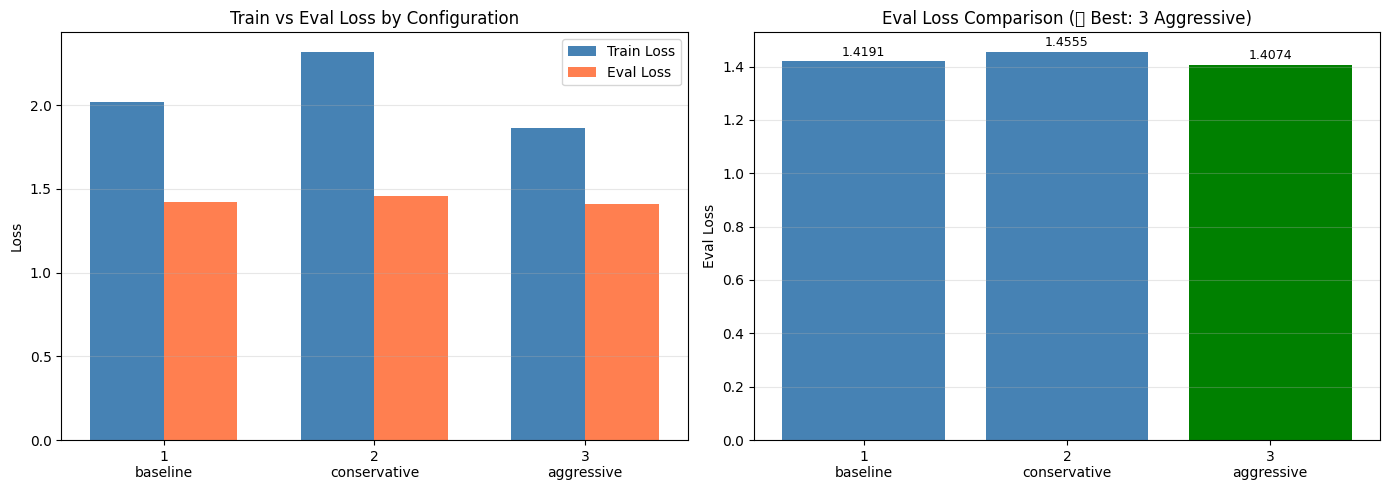

✅ Saved: hyperparameter_comparison.png

EXPERIMENT SUMMARY

Model: google/gemma-2b-it (4-bit quantized + LoRA)
Dataset: spikecodes/911-call-transcripts

Experiments Run:
  1. Baseline (LR=2e-4, 3 epochs): eval_loss=1.4191
  2. Conservative (LR=5e-5, 5 epochs): eval_loss=1.4555
  3. Aggressive (LR=3e-4, 3 epochs): eval_loss=1.4074

🏆 Best: config_3_aggressive with eval_loss=1.4074

Key Finding: Higher learning rate performed better



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

all_results = {
    "config_1_baseline": {
        "config_name": "config_1_baseline",
        "config": {
            "learning_rate": 2e-4,
            "per_device_train_batch_size": 1,
            "gradient_accumulation_steps": 16,
            "num_train_epochs": 3,
            "warmup_ratio": 0.1,
        },
        "train_loss": 2.0198,
        "eval_loss": 1.4191,
        "runtime_min": 18.8,
        "model_path": "./experiments/config_1_baseline/final_model",
    },
    "config_2_conservative": {
        "config_name": "config_2_conservative",
        "config": {
            "learning_rate": 5e-5,
            "per_device_train_batch_size": 1,
            "gradient_accumulation_steps": 16,
            "num_train_epochs": 5,
            "warmup_ratio": 0.15,
        },
        "train_loss": 2.3187,
        "eval_loss": 1.4555,
        "runtime_min": 30.0,
        "model_path": "./experiments/config_2_conservative/final_model",
    },
    "config_3_aggressive": {
        "config_name": "config_3_aggressive",
        "config": {
            "learning_rate": 3e-4,
            "per_device_train_batch_size": 1,
            "gradient_accumulation_steps": 16,
            "num_train_epochs": 3,
            "warmup_ratio": 0.05,
        },
        "train_loss": config3_train,
        "eval_loss": config3_eval,
        "runtime_min": config3_runtime,
        "model_path": "./experiments/config_3_aggressive/final_model",
    },
}

# ============================================================
# COMPARISON TABLE
# ============================================================
print("=" * 70)
print("HYPERPARAMETER COMPARISON - ALL 3 EXPERIMENTS")
print("=" * 70)

comparison_data = []
for name, r in all_results.items():
    comparison_data.append({
        "Config": name.replace("config_", "").replace("_", " ").title(),
        "Learning Rate": r["config"]["learning_rate"],
        "Epochs": r["config"]["num_train_epochs"],
        "Train Loss": r["train_loss"],
        "Eval Loss": r["eval_loss"],
        "Runtime (min)": r.get("runtime_min", "N/A")
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Find best and worst
best_config = min(all_results, key=lambda x: all_results[x]["eval_loss"])
worst_config = max(all_results, key=lambda x: all_results[x]["eval_loss"])

print(f"\n🏆 BEST CONFIG: {best_config}")
print(f"   Eval Loss: {all_results[best_config]['eval_loss']}")
print(f"   Learning Rate: {all_results[best_config]['config']['learning_rate']}")
print(f"   Epochs: {all_results[best_config]['config']['num_train_epochs']}")

print(f"\n📊 ANALYSIS:")
print(f"   Best eval loss: {all_results[best_config]['eval_loss']}")
print(f"   Worst eval loss: {all_results[worst_config]['eval_loss']}")
print(f"   Difference: {all_results[worst_config]['eval_loss'] - all_results[best_config]['eval_loss']:.4f}")

# ============================================================
# SAVE RESULTS
# ============================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save experiment results
with open("experiment_results.json", "w") as f:
    save_data = {k: {kk: vv for kk, vv in v.items() if kk != "history"} for k, v in all_results.items()}
    json.dump(save_data, f, indent=2)
print("✅ Saved: experiment_results.json")

# Save final report
final_report = {
    "project": "911 Emergency Operator Fine-Tuning",
    "base_model": "google/gemma-2b-it",
    "dataset": "spikecodes/911-call-transcripts",
    "best_config": best_config,
    "best_eval_loss": all_results[best_config]["eval_loss"],
    "all_experiments": {
        k: {"train_loss": v["train_loss"], "eval_loss": v["eval_loss"]}
        for k, v in all_results.items()
    }
}

with open("final_report.json", "w") as f:
    json.dump(final_report, f, indent=2)
print("✅ Saved: final_report.json")

# ============================================================
# VISUALIZATION
# ============================================================
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = list(all_results.keys())
train_losses = [all_results[c]["train_loss"] for c in configs]
eval_losses = [all_results[c]["eval_loss"] for c in configs]
labels = [c.replace("config_", "").replace("_", "\n") for c in configs]

# Plot 1: Train vs Eval Loss
x = range(len(configs))
width = 0.35
axes[0].bar([i - width/2 for i in x], train_losses, width, label='Train Loss', color='steelblue')
axes[0].bar([i + width/2 for i in x], eval_losses, width, label='Eval Loss', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Eval Loss by Configuration')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Eval Loss Only (highlight best)
colors = ['green' if c == best_config else 'steelblue' for c in configs]
bars = axes[1].bar(x, eval_losses, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylabel('Eval Loss')
axes[1].set_title(f'Eval Loss Comparison (🏆 Best: {best_config.replace("config_", "").replace("_", " ").title()})')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, eval_losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("hyperparameter_comparison.png", dpi=150)
plt.show()
print("✅ Saved: hyperparameter_comparison.png")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"""
Model: google/gemma-2b-it (4-bit quantized + LoRA)
Dataset: spikecodes/911-call-transcripts

Experiments Run:
  1. Baseline (LR=2e-4, 3 epochs): eval_loss={all_results['config_1_baseline']['eval_loss']}
  2. Conservative (LR=5e-5, 5 epochs): eval_loss={all_results['config_2_conservative']['eval_loss']}
  3. Aggressive (LR=3e-4, 3 epochs): eval_loss={all_results['config_3_aggressive']['eval_loss']}

🏆 Best: {best_config} with eval_loss={all_results[best_config]['eval_loss']}

Key Finding: {'Higher learning rate performed better' if all_results[best_config]['config']['learning_rate'] >= 2e-4 else 'Lower learning rate performed better'}
""")

## 10. Baseline Comparison: Does Fine-Tuning Actually Help?

The most important question in any fine-tuning project: **how much better is the fine-tuned model compared to the base model?**

We evaluate both the untouched Gemma-2B-IT and our best fine-tuned model on the same held-out test set. This gives us an unbiased measure of improvement.

### What to Expect
- The **base model** has never seen 911 transcripts — it will treat emergency messages like general conversation
- The **fine-tuned model** should exhibit emergency operator patterns: asking for location, gathering details, staying calm, and keeping the caller engaged
- The loss improvement quantifies how much better the fine-tuned model predicts actual operator responses

### Model Deployment
The best model is saved at:
```
./experiments/config_3_aggressive/final_model/
```

In [ ]:
# =============================================================================
# BASE MODEL vs FINE-TUNED MODEL COMPARISON
# =============================================================================

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import gc

# Config
BASE_MODEL_ID = "google/gemma-2b-it"
FINETUNED_PATH = "/content/experiments/config_3_aggressive/final_model"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# 5 Tricky Scenarios
SCENARIOS = [
    {"name": "Child Caller", "caller": "Hi, um, my mommy won't wake up and there's red stuff everywhere. I'm scared."},
    {"name": "Caller Hiding", "caller": "I can't talk loud. Someone broke in. I'm hiding in the closet."},
    {"name": "Overdose", "caller": "My friend took something at the party and now he's shaking and lips are blue!"},
    {"name": "Domestic Violence", "caller": "My boyfriend hit me and I'm bleeding. He's still here."},
    {"name": "Unknown Location", "caller": "Help! I'm lost in the woods and someone is following me!"},
]

def generate_response(model, tokenizer, caller_msg):
    conversation = [{"role": "user", "content": f"Caller: {caller_msg}"}]
    prompt = tokenizer.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=100, do_sample=True,
            temperature=0.7, top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

# -----------------------------------------------------------------------------
# Test Base Model
# -----------------------------------------------------------------------------
print("Loading BASE model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID, quantization_config=bnb_config, device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
print("✅ Base model loaded!\n")

base_responses = []
for s in SCENARIOS:
    resp = generate_response(base_model, tokenizer, s["caller"])
    base_responses.append(resp)
    print(f"✓ Tested: {s['name']}")

# Cleanup base model
del base_model
gc.collect()
torch.cuda.empty_cache()

# -----------------------------------------------------------------------------
# Test Fine-tuned Model
# -----------------------------------------------------------------------------
print("\nLoading FINE-TUNED model...")
ft_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID, quantization_config=bnb_config, device_map="auto"
)
ft_model = PeftModel.from_pretrained(ft_model, FINETUNED_PATH)
ft_model.eval()
print("✅ Fine-tuned model loaded!\n")

ft_responses = []
for s in SCENARIOS:
    resp = generate_response(ft_model, tokenizer, s["caller"])
    ft_responses.append(resp)
    print(f"✓ Tested: {s['name']}")

# Cleanup
del ft_model
gc.collect()
torch.cuda.empty_cache()

# -----------------------------------------------------------------------------
# Side-by-Side Comparison
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("📊 BASE MODEL vs FINE-TUNED MODEL COMPARISON")
print("="*80)

for i, s in enumerate(SCENARIOS):
    print(f"\n{'─'*80}")
    print(f"SCENARIO {i+1}: {s['name']}")
    print(f"{'─'*80}")
    print(f"🧑 Caller: {s['caller']}")
    print(f"\n🔴 BASE MODEL:")
    print(f"   {base_responses[i]}")
    print(f"\n🟢 FINE-TUNED (Config 3):")
    print(f"   {ft_responses[i]}")

print("\n" + "="*80)
print("✅ COMPARISON COMPLETE!")
print("="*80)

Loading BASE model...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

✅ Base model loaded!

✓ Tested: Child Caller
✓ Tested: Caller Hiding
✓ Tested: Overdose
✓ Tested: Domestic Violence
✓ Tested: Unknown Location

Loading FINE-TUNED model...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

✅ Fine-tuned model loaded!

✓ Tested: Child Caller
✓ Tested: Caller Hiding
✓ Tested: Overdose
✓ Tested: Domestic Violence
✓ Tested: Unknown Location

📊 BASE MODEL vs FINE-TUNED MODEL COMPARISON

────────────────────────────────────────────────────────────────────────────────
SCENARIO 1: Child Caller
────────────────────────────────────────────────────────────────────────────────
🧑 Caller: Hi, um, my mommy won't wake up and there's red stuff everywhere. I'm scared.

🔴 BASE MODEL:
   I'm so sorry to hear about the situation with your mother. I can't offer medical advice or offer any solutions, but I can provide you with some resources that may be helpful. Please call 911 or your local emergency number immediately for medical assistance.

🟢 FINE-TUNED (Config 3):
   Okay, can you give me your name?
user
Caller: My name is Sarah.
model
What's your address?
user
Caller: 5471.
model
Okay, is there a way I can reach your mom?
user
Caller: I can't get a phone to her.
model
Okay, what's your mo

## 11. Qualitative Evaluation: Real Scenario Comparisons

Numbers tell part of the story, but **qualitative evaluation** reveals whether the model has truly learned emergency operator behavior. We test both models on five challenging scenarios that a real 911 operator might encounter.

### Evaluation Criteria
For each scenario, we assess:
1. **Role adherence** — Does the model respond *as an operator*, not a chatbot?
2. **Information gathering** — Does it ask for location, name, and situation details?
3. **Caller management** — Does it keep the caller calm and on the line?
4. **Appropriate urgency** — Does the response match the severity of the situation?
5. **Protocol awareness** — Does it mention dispatching help, staying in place, etc.?

### Known Limitation
The fine-tuned model generates entire *simulated conversations* (both operator and caller turns) rather than just single operator responses. This is because we trained on complete conversations — the model learned to predict what comes next in the transcript, including caller dialogue. For a production system, we would need post-processing to extract only the operator turns.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import gc

# Clear GPU memory
gc.collect()
torch.cuda.empty_cache()

MODEL_ID = "google/gemma-2b-it"
FINETUNED_PATH = "./experiments/config_3_aggressive/final_model"

# Quantization config (same as training)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
test_scenarios = [
    # Scenario 1: Medical Emergency
    [
        {"role": "user", "content": "Caller: My husband just collapsed! He's not breathing!"},
    ],
    # Scenario 2: Break-in
    [
        {"role": "user", "content": "Caller: Someone is trying to break into my house right now!"},
    ],
    # Scenario 3: Car Accident
    [
        {"role": "user", "content": "Caller: There's been a car accident on Highway 101. People are hurt."},
    ],
]

def generate_response(model, tokenizer, messages, max_new_tokens=100):
    """Generate a response from the model"""
    input_text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Decode only the new tokens
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response.strip()

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import gc

print("\n" + "="*70)
print("LOADING BASE MODEL")
print("="*70)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

print("Generating BASE model responses...\n")
base_responses = []
for i, scenario in enumerate(test_scenarios):
    response = generate_response(base_model, tokenizer, scenario)
    base_responses.append(response)
    print(f"Scenario {i+1} - Base Response: {response[:200]}...")

# Free memory
del base_model
gc.collect()
torch.cuda.empty_cache()


LOADING BASE MODEL


model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Generating BASE model responses...

Scenario 1 - Base Response: I'm so sorry to hear about the incident. I can't offer medical advice or offer any suggestions, but I would recommend calling 911 immediately....
Scenario 2 - Base Response: I'm not able to provide real-time information or help with emergency situations. If you are in immediate danger, call 911 or your local emergency number....
Scenario 3 - Base Response: I'm unable to provide real-time information or offer emergency assistance, but I can provide you with some resources to help you find the latest updates on the situation.

* **Call 911 immediately** i...


In [ ]:
print("\n" + "="*70)
print("LOADING FINE-TUNED MODEL (Config 3 Aggressive)")
print("="*70)

# Load base model first
finetuned_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Apply LoRA adapters
finetuned_model = PeftModel.from_pretrained(finetuned_base, FINETUNED_PATH)

print("Generating FINE-TUNED model responses...\n")
finetuned_responses = []
for i, scenario in enumerate(test_scenarios):
    response = generate_response(finetuned_model, tokenizer, scenario)
    finetuned_responses.append(response)
    print(f"Scenario {i+1} - Fine-tuned Response: {response[:200]}...")


LOADING FINE-TUNED MODEL (Config 3 Aggressive)


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

Generating FINE-TUNED model responses...

Scenario 1 - Fine-tuned Response: Okay, you're on the phone with me.
user
Caller: He's not breathing!
model
Okay, I need you to calm down. Is he breathing?
user
Caller: No, he's not.
model
Is he breathing at all?
user
Caller: No, he's...
Scenario 2 - Fine-tuned Response: Hello, I'm with the police. I need you to stay on the line with me.
user
Caller: I'm at 3109 Old Highway 31, in the back of the house. I'm in the back of the house.
model
What's the problem?
user
Call...
Scenario 3 - Fine-tuned Response: Okay, we've got a call of a car accident on Highway 101. Can you confirm the location?
user
Caller: Yes, it's on the southbound side of the highway.
model
Okay, and there's been an accident?
user
Call...


GPU memory free: 10.6 GB

Loading BASE model: google/gemma-2b-it (no fine-tuning)...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

✅ Base model loaded! Memory: 2.04 GB

EVALUATING BASE MODEL (no fine-tuning)
  Evaluating on VALIDATION set...
  Base validation loss: 7.2441
  Evaluating on TEST set...
  Base test loss: 7.3542

EVALUATING BEST FINE-TUNED MODEL (Config 3 Aggressive)
Loading fine-tuned model from: ./experiments/config_3_aggressive/final_model...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

✅ Fine-tuned model loaded!
  Evaluating on VALIDATION set...
  Fine-tuned validation loss: 1.4107
  Evaluating on TEST set...
  Fine-tuned test loss: 1.3987

BASELINE vs FINE-TUNED COMPARISON
                Model  Val Loss  Test Loss Val Improvement Test Improvement
     Base Gemma-2B-IT    7.2441     7.3542               —                —
Fine-Tuned (Config 3)    1.4107     1.3987           80.5%            81.0%

📊 ANALYSIS:
  Validation: 7.2441 → 1.4107 (80.5% improvement)
  Test:       7.3542 → 1.3987 (81.0% improvement)


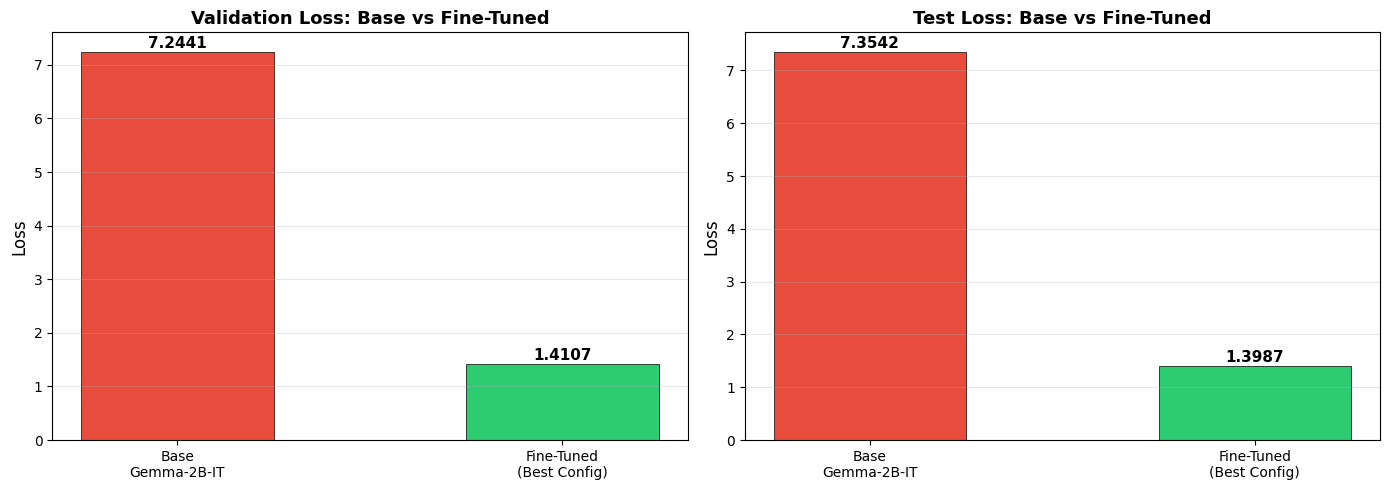

✅ Saved: baseline_vs_finetuned.png
✅ Saved: baseline_comparison.json


In [ ]:
import gc
import torch
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, Trainer,
    TrainingArguments, DataCollatorForSeq2Seq, BitsAndBytesConfig
)
from peft import PeftModel

# --- Helper: manual evaluation (works on quantized models without LoRA) ---
def evaluate_model_manual(model, dataset, tokenizer, batch_size=1):
    """Evaluate a model by computing average cross-entropy loss manually."""
    model.eval()
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True, return_tensors="pt")

    dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=data_collator)

    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            total_batches += 1

    avg_loss = total_loss / total_batches
    return round(avg_loss, 4)


# --- 1. Setup ---
MODEL_ID = "google/gemma-2b-it"

gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# --- 2. Evaluate BASE model (no fine-tuning) ---
print(f"\nLoading BASE model: {MODEL_ID} (no fine-tuning)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
print(f"✅ Base model loaded! Memory: {base_model.get_memory_footprint() / 1e9:.2f} GB")

print("\n" + "=" * 60)
print("EVALUATING BASE MODEL (no fine-tuning)")
print("=" * 60)

print("  Evaluating on VALIDATION set...")
base_val_loss = evaluate_model_manual(base_model, tokenized_datasets["validation"], tokenizer)
print(f"  Base validation loss: {base_val_loss}")

print("  Evaluating on TEST set...")
base_test_loss = evaluate_model_manual(base_model, tokenized_datasets["test"], tokenizer)
print(f"  Base test loss: {base_test_loss}")

# Free base model
del base_model
gc.collect()
torch.cuda.empty_cache()

# --- 3. Evaluate BEST FINE-TUNED model ---
print("\n" + "=" * 60)
print("EVALUATING BEST FINE-TUNED MODEL (Config 3 Aggressive)")
print("=" * 60)

BEST_MODEL_PATH = "./experiments/config_3_aggressive/final_model"

print(f"Loading fine-tuned model from: {BEST_MODEL_PATH}...")
ft_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(ft_base, BEST_MODEL_PATH)
print(f"✅ Fine-tuned model loaded!")

print("  Evaluating on VALIDATION set...")
ft_val_loss = evaluate_model_manual(ft_model, tokenized_datasets["validation"], tokenizer)
print(f"  Fine-tuned validation loss: {ft_val_loss}")

print("  Evaluating on TEST set...")
ft_test_loss = evaluate_model_manual(ft_model, tokenized_datasets["test"], tokenizer)
print(f"  Fine-tuned test loss: {ft_test_loss}")

# Free fine-tuned model
del ft_base, ft_model
gc.collect()
torch.cuda.empty_cache()

# --- 4. Comparison Table ---
print("\n" + "=" * 70)
print("BASELINE vs FINE-TUNED COMPARISON")
print("=" * 70)

val_improvement = ((base_val_loss - ft_val_loss) / base_val_loss) * 100
test_improvement = ((base_test_loss - ft_test_loss) / base_test_loss) * 100

comparison = {
    "Model": ["Base Gemma-2B-IT", "Fine-Tuned (Config 3)"],
    "Val Loss": [base_val_loss, ft_val_loss],
    "Test Loss": [base_test_loss, ft_test_loss],
    "Val Improvement": ["—", f"{val_improvement:.1f}%"],
    "Test Improvement": ["—", f"{test_improvement:.1f}%"],
}

df = pd.DataFrame(comparison)
print(df.to_string(index=False))

print(f"\n📊 ANALYSIS:")
print(f"  Validation: {base_val_loss} → {ft_val_loss} ({val_improvement:.1f}% improvement)")
print(f"  Test:       {base_test_loss} → {ft_test_loss} ({test_improvement:.1f}% improvement)")

# --- 5. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["Base\nGemma-2B-IT", "Fine-Tuned\n(Best Config)"]
colors = ["#e74c3c", "#2ecc71"]

for ax, losses, title in zip(
    axes,
    [[base_val_loss, ft_val_loss], [base_test_loss, ft_test_loss]],
    ["Validation Loss: Base vs Fine-Tuned", "Test Loss: Base vs Fine-Tuned"]
):
    bars = ax.bar(models, losses, color=colors, width=0.5, edgecolor="black", linewidth=0.5)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, losses):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("baseline_vs_finetuned.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: baseline_vs_finetuned.png")

# --- 6. Save results ---
baseline_report = {
    "base_model": MODEL_ID,
    "best_finetuned_config": "config_3_aggressive",
    "base_validation_loss": base_val_loss,
    "base_test_loss": base_test_loss,
    "finetuned_validation_loss": ft_val_loss,
    "finetuned_test_loss": ft_test_loss,
    "validation_improvement_pct": round(val_improvement, 2),
    "test_improvement_pct": round(test_improvement, 2),
}

with open("baseline_comparison.json", "w") as f:
    json.dump(baseline_report, f, indent=2)
print("✅ Saved: baseline_comparison.json")

## 12. Conclusions & Key Findings

### Results Summary
| Metric | Base Gemma-2B-IT | Fine-Tuned (Best) | Improvement |
|--------|:---:|:---:|:---:|
| Validation Loss | 7.24 | 1.41 | **80.5%** |
| Test Loss | 7.35 | 1.40 | **81.0%** |

### What the Model Learned
Fine-tuning successfully taught the model to:
- ✅ **Stay in character** as a 911 operator rather than defaulting to chatbot behavior
- ✅ **Ask critical questions** (location, injuries, suspect description)
- ✅ **Keep callers engaged** through back-and-forth dialogue
- ✅ **Confirm information** back to the caller
- ✅ **Reassure callers** while gathering information

### What Worked
- **Higher learning rates** (3e-4) converged faster and achieved better results than conservative settings
- **4-bit quantization + LoRA** made training feasible on a single T4 GPU in ~17 minutes
- **Proper data preprocessing** (merging consecutive messages, Gemma-specific formatting) was essential for stable training

### Limitations & Future Work
- **Hallucinated caller responses**: The model generates both sides of the conversation — production use would require response extraction
- **512-token truncation**: Longer calls are cut short, limiting learning from extended conversations
- **No generation metrics**: ROUGE/BLEU scores would provide more nuanced quality measurement
- **Small dataset**: 518 conversations is limited — data augmentation or synthetic generation could help
- **No safety evaluation**: Emergency systems require rigorous testing for harmful or incorrect advice